## Optimization for Contract Design


Install gurobipy

In [8]:
!pip install gurobipy

## Define distribution of Gates Foundation's belief on the drug's success rate

Here we use a beta distribution.  You can change the values of $a$ and $b$ and try different shapes of the beta distribution.


Discretized values (x):
[0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909 0.1010101  0.11111111
 0.12121212 0.13131313 0.14141414 0.15151515 0.16161616 0.17171717
 0.18181818 0.19191919]

PDF values:
[0.00000000e+00 3.09151500e-07 4.89595028e-06 2.45302251e-05
 7.67200456e-05 1.85333169e-04 3.80218489e-04 6.96827480e-04
 1.17583565e-03 1.86276397e-03]


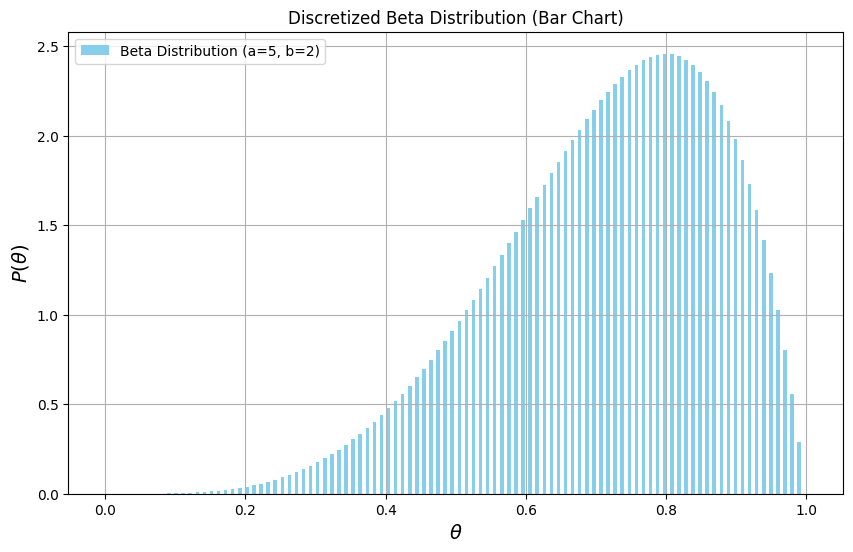

In [9]:
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

# Define the parameters of the beta distribution
a = 5
b = 2

# Create a beta distribution object
beta_dist = beta(a, b)

# Generate 100 evenly spaced values between 0 and 1
x = np.linspace(0, 1, 100)

# Calculate the probability density function (PDF) at these values
pdf_values = beta_dist.pdf(x)

# Display the first few values of x and the corresponding PDF values
print("Discretized values (x):")
print(x[:20])
print("\nPDF values:")
print(pdf_values[:10])

# Create the plot
plt.figure(figsize=(10, 6))
plt.bar(x, pdf_values, label=f'Beta Distribution (a={a}, b={b})', color='skyblue', width=0.5/len(x))

# Add titles and labels
plt.title('Discretized Beta Distribution (Bar Chart)')
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel(r'$P(\theta)$', fontsize=14)
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

## Setting model parameters

In [10]:
# Set model parameters
alpha = 0.5
delta = 0.6
pi = 300
omega = 400
c = 100

# Create a sequence of 100 values for tau between 0 and 1
tau_values = np.linspace(0, 1, 100)
display(tau_values)

array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404,
       0.05050505, 0.06060606, 0.07070707, 0.08080808, 0.09090909,
       0.1010101 , 0.11111111, 0.12121212, 0.13131313, 0.14141414,
       0.15151515, 0.16161616, 0.17171717, 0.18181818, 0.19191919,
       0.2020202 , 0.21212121, 0.22222222, 0.23232323, 0.24242424,
       0.25252525, 0.26262626, 0.27272727, 0.28282828, 0.29292929,
       0.3030303 , 0.31313131, 0.32323232, 0.33333333, 0.34343434,
       0.35353535, 0.36363636, 0.37373737, 0.38383838, 0.39393939,
       0.4040404 , 0.41414141, 0.42424242, 0.43434343, 0.44444444,
       0.45454545, 0.46464646, 0.47474747, 0.48484848, 0.49494949,
       0.50505051, 0.51515152, 0.52525253, 0.53535354, 0.54545455,
       0.55555556, 0.56565657, 0.57575758, 0.58585859, 0.5959596 ,
       0.60606061, 0.61616162, 0.62626263, 0.63636364, 0.64646465,
       0.65656566, 0.66666667, 0.67676768, 0.68686869, 0.6969697 ,
       0.70707071, 0.71717172, 0.72727273, 0.73737374, 0.74747

## Solving a sequence of linear optimization

For each threshold $\tau$ value, we define an optimization problem.

In [11]:
from gurobipy import Model, GRB, quicksum
import numpy as np

results = []

for tau in tau_values:
    # Create a new model for each tau value
    model = Model("optimization_model")

    # Define decision variables
    m0 = model.addVar(vtype=GRB.CONTINUOUS, name="m0", lb=0.0)
    mS = model.addVar(vtype=GRB.CONTINUOUS, name="mS", lb=0.0)
    mF = model.addVar(vtype=GRB.CONTINUOUS, name="mF", lb=0.0)

    # Update the model to include the variables
    model.update()

    # Add constraints
   # Constraint 1: m0 + delta * (tau * mS + (1 - tau) * mF) == c - delta * pi * tau
    model.addConstr(m0 + delta * (tau * (mS+pi) + (1 - tau) * mF) <= c, "constraint1_low")
    tau_next = tau+1/(len(tau_values)-1)
    print(tau, tau_next)
    model.addConstr(m0 + delta * (tau_next * (mS+pi) + (1 - tau_next) * mF) >= c, "constraint1_high")

    # Constraint 2: m0 + delta * mF <= alpha * c
    model.addConstr(m0 + delta * mF <= alpha * c, "constraint2")

    # Set objective function using quicksum
    objective = quicksum((x[i] * omega - m0 - x[i] * mS - (1 - x[i]) * mF) * pdf_values[i] for i in range(len(x)) if x[i]>=tau)

    model.setObjective(objective, GRB.MAXIMIZE) # Assuming maximization based on the expression

    # Optimize the model
    model.optimize()

    # Store results if the model is solvable
    if model.status == GRB.OPTIMAL:
        results.append({
            'tau': tau,
            'm0': m0.X,
            'mS': mS.X,
            'mF': mF.X,
            'objective_value': model.ObjVal
        })
    else:
        results.append({
            'tau': tau,
            'status': model.status
        })

    print("see me!", model.status)

# You can then process or display the results
# import pandas as pd
# results_df = pd.DataFrame(results)
# display(results_df)

# Print a message indicating the loop has finished
print("Optimization loop finished. Objective function added using quicksum. Results are stored in the 'results' list (if optimization and result storage code is uncommented).")

0.0 0.010101010101010102
Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 3 rows, 3 columns and 7 nonzeros (Max)
Model fingerprint: 0x2af92e5c
Model has 3 linear objective coefficients and an objective constant of -2.8275614306193373e+04
Coefficient statistics:
  Matrix range     [6e-03, 1e+00]
  Objective range  [3e+01, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+01, 1e+02]

Presolve removed 1 rows and 0 columns
Presolve time: 0.01s
Presolved: 2 rows, 3 columns, 5 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.8275614e+04   1.227273e+01   0.000000e+00      0s
       2   -5.3865096e+05   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.01 seconds (0.00 work units)
Optimal objective -5.386509575e+05
see me

## Plot the sequence of optimal objective values

The best of the optimal objective values yield the optimal threshold $\tau$ as well as the contract terms.

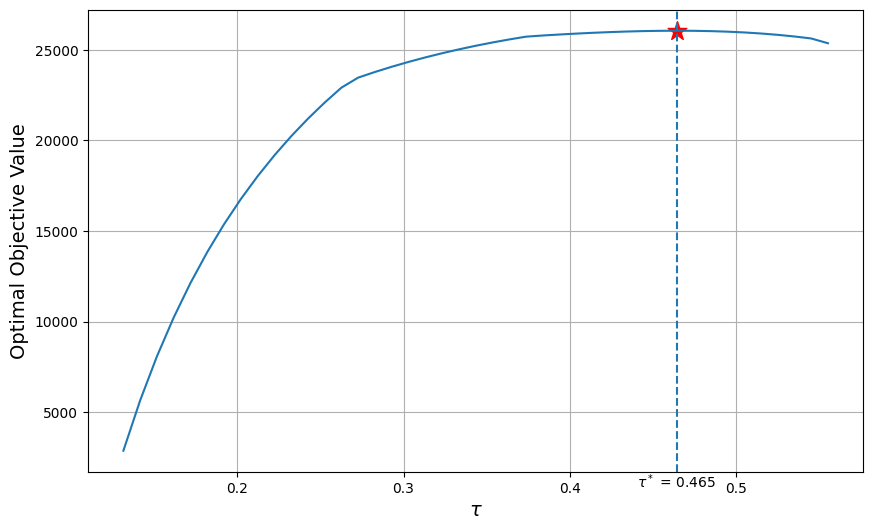

Maximum Optimal Objective Value: 26056.024213112818
Corresponding m0: 0.0
Corresponding mS: 0.0
Corresponding mF: 46.15384615384616
Corresponding tau: 0.4646464646464647


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_optimization_results(results):
    """
    Plots the optimal objective value vs. tau and highlights the maximum.

    Args:
        results (list): A list of dictionaries containing optimization results.
    """
    # Convert results to a pandas DataFrame for easier plotting
    results_df = pd.DataFrame(results)

    # Filter for optimal solutions
    optimal_results = results_df[results_df['objective_value'] > 0]

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(optimal_results['tau'], optimal_results['objective_value'])

    # Find the row with the maximum objective value
    if not optimal_results.empty:
        max_objective_row = optimal_results.loc[optimal_results['objective_value'].idxmax()]
        plt.scatter(max_objective_row['tau'], max_objective_row['objective_value'], color='red', marker='*', s=200, label='Maximum Objective')
        plt.axvline(max_objective_row['tau'], linestyle='--', label=f'Optimal \u03C4 = {max_objective_row["tau"]:.4f}')
        plt.text(max_objective_row['tau'], plt.ylim()[0], r'$\tau^*$ = {:.3f}'.format(max_objective_row['tau']), ha='center', va='top')
        # Add titles and labels
        plt.xlabel(r'$\tau$', fontsize=14)
        plt.ylabel('Optimal Objective Value', fontsize=14)
        plt.grid(True)
        plt.show()

        max_objective_value = max_objective_row['objective_value']
        optimal_m0 = max_objective_row['m0']
        optimal_mS = max_objective_row['mS']
        optimal_mF = max_objective_row['mF']
        optimal_tau = max_objective_row['tau']
        print(f"Maximum Optimal Objective Value: {max_objective_value}")
        print(f"Corresponding m0: {optimal_m0}")
        print(f"Corresponding mS: {optimal_mS}")
        print(f"Corresponding mF: {optimal_mF}")
        print(f"Corresponding tau: {optimal_tau}")

# To use the function, call it with your results list:
plot_optimization_results(results)

## What if we do not fund failure (forcing $m_F=0$)?

In [13]:
from gurobipy import Model, GRB, quicksum
import numpy as np

results = []

for tau in tau_values:
    # Create a new model for each tau value
    model = Model("optimization_model")

    # Define decision variables
    m0 = model.addVar(vtype=GRB.CONTINUOUS, name="m0", lb=0.0)
    mS = model.addVar(vtype=GRB.CONTINUOUS, name="mS", lb=0.0)
    mF = model.addVar(vtype=GRB.CONTINUOUS, name="mF", lb=0.0)

    # Update the model to include the variables
    model.update()

    # Add constraints
    # Constraint 1: m0 + delta * (tau * mS + (1 - tau) * mF) == c - delta * pi * tau
    model.addConstr(m0 + delta * (tau * (mS+pi) + (1 - tau) * mF) <= c, "constraint1_low")
    tau_next = tau+1/(len(tau_values)-1)
    print(tau, tau_next)
    model.addConstr(m0 + delta * (tau_next * (mS+pi) + (1 - tau_next) * mF) >= c, "constraint1_high")

    # Constraint 2: m0 + delta * mF <= alpha * c
    model.addConstr(m0 + delta * mF <= alpha * c, "constraint2")

    # ADD CONSTRAINT: No fund for failure
    model.addConstr(mF == 0, "No Fund for Failure")

    # Set objective function using quicksum
    objective = quicksum((x[i] * omega - m0 - x[i] * mS - (1 - x[i]) * mF) * pdf_values[i] for i in range(len(x)) if x[i]>=tau)

    model.setObjective(objective, GRB.MAXIMIZE) # Assuming maximization based on the expression

    # Optimize the model
    model.optimize()

    # Store results if the model is solvable
    if model.status == GRB.OPTIMAL:
        results.append({
            'tau': tau,
            'm0': m0.X,
            'mS': mS.X,
            'mF': mF.X,
            'objective_value': model.ObjVal
        })
    else:
        results.append({
            'tau': tau,
            'status': model.status
        })

    print("see me!", model.status)

# You can then process or display the results
# import pandas as pd
# results_df = pd.DataFrame(results)
# display(results_df)

# Print a message indicating the loop has finished
print("Optimization loop finished. Objective function added using quicksum. Results are stored in the 'results' list (if optimization and result storage code is uncommented).")

0.0 0.010101010101010102
Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 4 rows, 3 columns and 8 nonzeros (Max)
Model fingerprint: 0x1c759874
Model has 3 linear objective coefficients and an objective constant of -2.8275614306193373e+04
Coefficient statistics:
  Matrix range     [6e-03, 1e+00]
  Objective range  [3e+01, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+01, 1e+02]

Presolve removed 4 rows and 3 columns
Presolve time: 0.04s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -5.3865096e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.05 seconds (0.00 work units)
Optimal objective -5.386509575e+05
see me! 2
0.010101010101010102 0.020202020202020204
Gurobi Optimizer vers

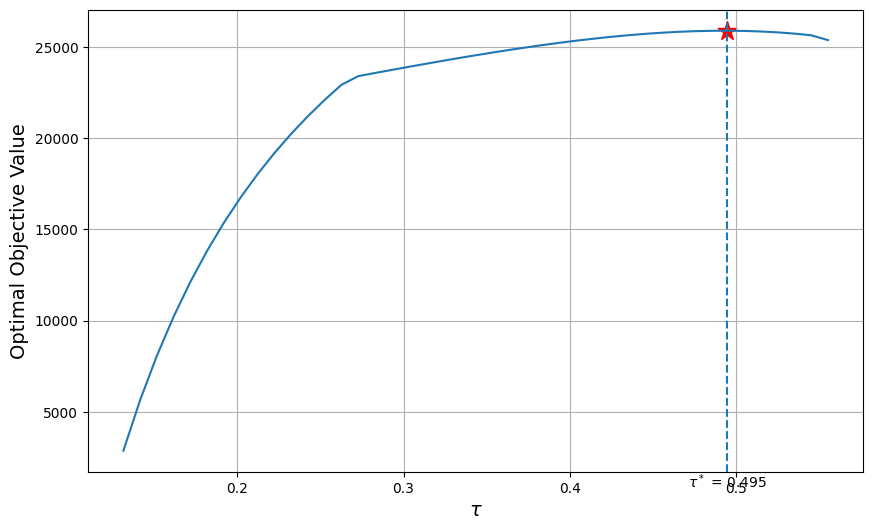

Maximum Optimal Objective Value: 25878.787674738956
Corresponding m0: 9.09090909090908
Corresponding mS: 0.0
Corresponding mF: 0.0
Corresponding tau: 0.494949494949495


In [14]:
plot_optimization_results(results)